<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-II/blob/main/Algoritmo_de_metropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="#1F4E79">ALGORITMO DE METROPOLIS </font>

## <font color="#2E75B6">1. Planteamiento del problema</font>

Se desea implementar en Python el **algoritmo de Metropolis** para simular el vector

$$
X=(X_1,X_2)
$$

que sigue la función de densidad de probabilidad dada en clase:

$$
f(x)
=
c\exp\left[
-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}
\right],
$$

donde

$$
c=\frac{1}{20216.335877}.
$$

El algoritmo de Metropolis permite generar una muestra de la distribución objetivo mediante una cadena de Markov. Para ello, a partir del estado actual $X_t$ se propone un nuevo valor $Y$ y se determina si este valor se acepta o si la cadena permanece en $X_t$.

En este caso se utilizará una **caminata aleatoria**, de acuerdo con el procedimiento presentado en las notas de clase.

## <font color="#2E75B6">2. Definición de la función objetivo</font>

Primero se define en Python la función $f(x)$ dada en clase. Como el vector es

$$
x=(x_1,x_2),
$$

la función recibe los valores $x_1$ y $x_2$ y calcula

$$
f(x)
=
c\exp\left[
-\frac{x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2}{2}
\right].
$$

Esta función se utilizará posteriormente para calcular la probabilidad de aceptación del algoritmo de Metropolis.

In [ ]:
# Se importa NumPy para realizar los cálculos numéricos
import numpy as np

# Constante de normalización dada en clase
c = 1 / 20216.335877

# Se define la función objetivo f(x)
def f(x):
    x1 = x[0]
    x2 = x[1]

    return c * np.exp(
        -(x1**2 * x2**2 + x1**2 + x2**2 - 8*x1 - 8*x2) / 2
    )

## <font color="#2E75B6">3. Gráfica de la función objetivo</font>

Antes de aplicar el algoritmo de Metropolis, se realiza la gráfica de la función objetivo $f(x)$ para observar su comportamiento en términos de las dos componentes del vector

$$
X=(X_1,X_2).
$$

Como la función depende de $x_1$ y $x_2$, se utilizará una gráfica de superficie en tres dimensiones, donde los ejes horizontales corresponden a $x_1$ y $x_2$, mientras que la altura representa el valor de $f(x)$.

Para construir la superficie se genera una malla de valores de $x_1$ y $x_2$ y se evalúa en cada punto la función $f(x)$ definida anteriormente.

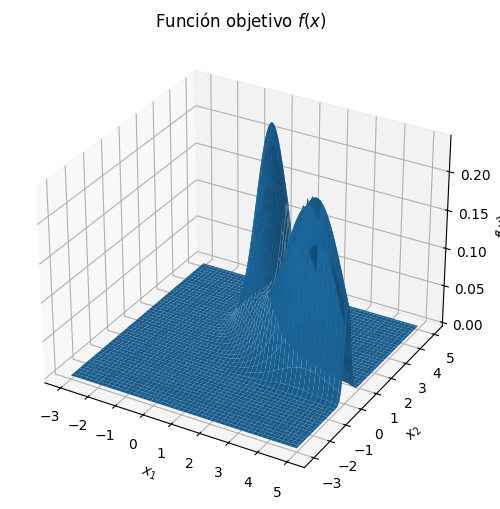

In [ ]:
# Se importa la librería necesaria para realizar la gráfica
import matplotlib.pyplot as plt

# Valores de x1 y x2 para construir la malla
x1 = np.linspace(-3, 5, 100)
x2 = np.linspace(-3, 5, 100)

# Se construye la malla con los valores de x1 y x2
X1, X2 = np.meshgrid(x1, x2)

# Se evalúa la función f(x) en cada punto de la malla
F = f([X1, X2])

# Se crea la gráfica de superficie
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, F)

# Título y nombres de los ejes
ax.set_title('Función objetivo $f(x)$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$f(x)$')

plt.show()

## <font color="#2E75B6">4. Propuesta y caminata aleatoria</font>

De acuerdo con el algoritmo de Metropolis-Hastings, dado el estado actual $X_t$, se genera un nuevo valor candidato $Y$ mediante una distribución propuesta $q(x,y)$.

En este caso, la propuesta $q(x,y)$ se elige **simétrica**, es decir,

$$
q(x,y)=q(y,x).
$$

Para generar el nuevo valor candidato se utiliza una **caminata aleatoria**. De acuerdo con las notas de clase, se generan dos variables aleatorias normales independientes:

$$
Z_1,Z_2\sim N(0,1).
$$

Después se forma el vector

$$
Z=(Z_1,Z_2)
$$

y el nuevo valor propuesto se obtiene mediante

$$
Y=X_t+Z.
$$

De esta manera, el candidato $Y$ se obtiene realizando un desplazamiento aleatorio a partir del estado actual $X_t$.